# Workshop PtX Kenya

Base: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb

Adapted: Alexander Meisinger, OTH Regensburg

Project: H2Global meets Afria

## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import warnings

## Path settings

In [2]:
# Network file
results_path = "/home/alex-charly/SSD/H2GMA/Github/AP2/ind-scenario/Kenya/pypsa-earth/results/Kenya_geo_pot_el_28_exp_350NH3_5MeOH_10GW/networks/elec_s_2_ec_lcopt_Co2L0.00-1H.nc"
network_path = "/home/alex-charly/SSD/H2GMA/Github/AP2/ind-scenario/Kenya/pypsa-earth/networks/Kenya_geo_pot_el_28/elec.nc"

# Country shape file
regions_onshore_path = "/home/alex-charly/SSD/H2GMA/Github/AP2/ind-scenario/Kenya/pypsa-earth/resources/Kenya_geo_pot_el_28/shapes/country_shapes.geojson"
# Renewable profile file
solar_path = "/home/alex-charly/SSD/H2GMA/Github/AP2/ind-scenario/Kenya/pypsa-earth/resources/Kenya_geo_pot_el_28/renewable_profiles/profile_solar.nc"
onwind_path = "/home/alex-charly/SSD/H2GMA/Github/AP2/ind-scenario/Kenya/pypsa-earth/resources/Kenya_geo_pot_el_28/renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [3]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_2_ec_lcopt_Co2L0.00-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/alex-charly/anaconda3/envs/pypsa-earth-AP2-same/lib/python3.11/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


## Data import check

Country check

Text(0.5, 1.0, 'KE')

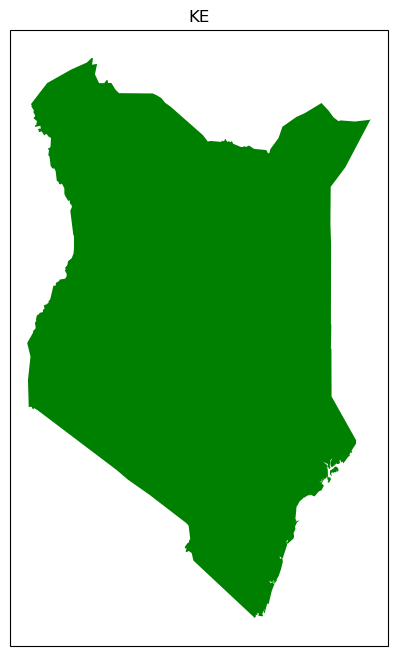

In [4]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [5]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 51 entries
Component 'Carrier' has 18 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 24 entries
Component 'LineType' has 35 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 68 entries
Component 'Load' has 17 entries
Component 'Generator' has 102 entries
Component 'StorageUnit' has 3 entries
Component 'Store' has 34 entries


Snapshot check

In [6]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 01:00:00',
               '2013-01-01 02:00:00', '2013-01-01 03:00:00',
               '2013-01-01 04:00:00', '2013-01-01 05:00:00',
               '2013-01-01 06:00:00', '2013-01-01 07:00:00',
               '2013-01-01 08:00:00', '2013-01-01 09:00:00',
               ...
               '2013-12-31 14:00:00', '2013-12-31 15:00:00',
               '2013-12-31 16:00:00', '2013-12-31 17:00:00',
               '2013-12-31 18:00:00', '2013-12-31 19:00:00',
               '2013-12-31 20:00:00', '2013-12-31 21:00:00',
               '2013-12-31 22:00:00', '2013-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)
Time steps: 8760


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/alex-charly/anaconda3/envs/pypsa-earth-AP2-same/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


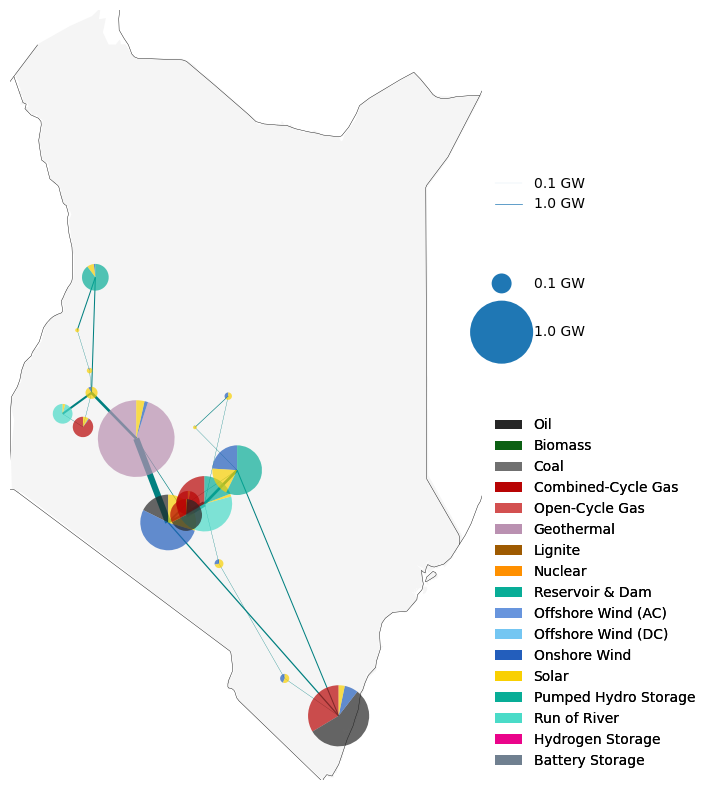

In [7]:
# Scale settings
bus_scale = 3e3 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

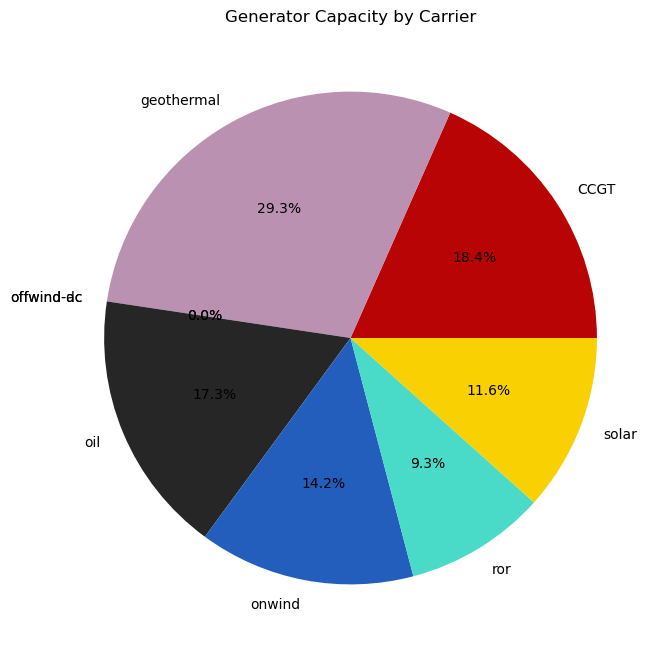

In [8]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
plt.pie(generator_capacity_by_carrier, labels=generator_capacity_by_carrier.index, autopct='%1.1f%%', colors=n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index))
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [9]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          0.565100
geothermal    0.900000
offwind-ac    0.000000
offwind-dc    0.000000
oil           0.532479
onwind        0.435817
ror           0.285000
solar         0.357807
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/alex-charly/anaconda3/envs/pypsa-earth-AP2-same/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


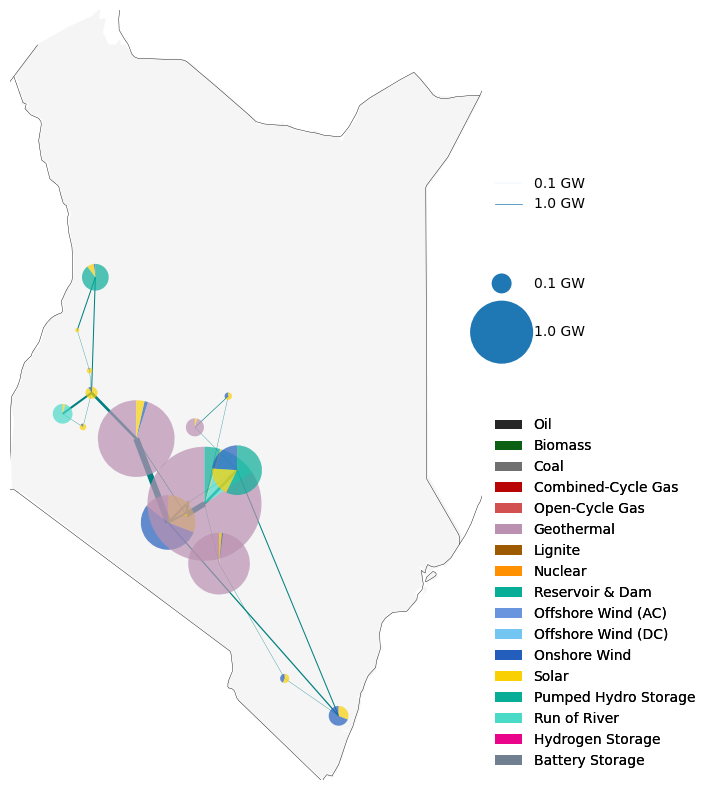

In [10]:
bus_scale = 3e3 
line_scale = 2e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") 
                   & (n.generators.carrier != "export") 
                   & (n.generators.carrier != "oil") # No usage of oil & CCGT (see energy balance)
                   & (n.generators.carrier != "CCGT")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Plot the future generation capacity (total) of the energy system - tabular chart

In [15]:
n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)

carrier
Combined-Cycle Gas    5.651000e-01
Geothermal            3.382458e+00
Offshore Wind (AC)    1.100000e-07
Offshore Wind (DC)    9.000000e-08
Oil                   5.324789e-01
Onshore Wind          4.358175e-01
Run of River          2.850000e-01
Solar                 3.578081e-01
load                  5.100000e+07
Name: p_nom_opt, dtype: float64

Analys the future generation capacity expansion of the energy system - table chart

In [16]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion

carrier
Combined-Cycle Gas    0.000000e+00
Geothermal            2.482458e+00
Offshore Wind (AC)             NaN
Offshore Wind (DC)             NaN
Oil                   0.000000e+00
Onshore Wind          4.900000e-07
Run of River          0.000000e+00
Solar                 1.080000e-06
load                  0.000000e+00
dtype: float64

Analys the future generation capacity expansion of the energy system - bar chart

<Axes: title={'center': 'Generator capacity expansion in GW'}, xlabel='carrier'>

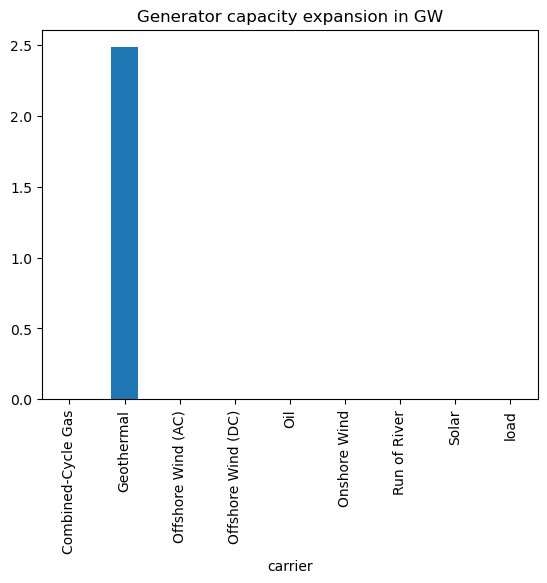

In [17]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Analyse the future energy generation of the energy system - bar chart view

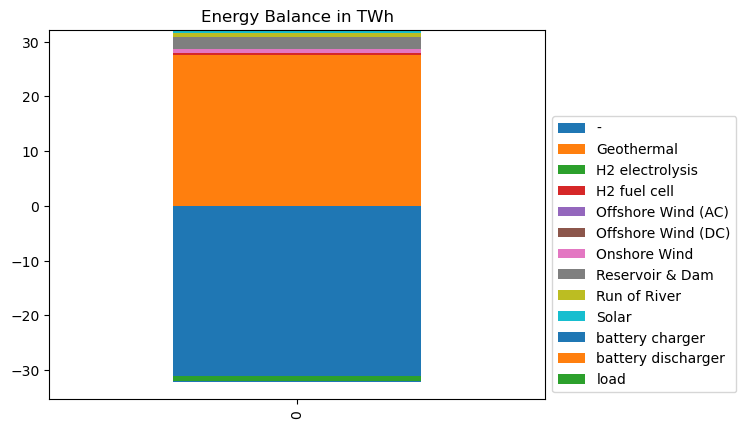

In [18]:
fig, ax = plt.subplots()
color_setting = n.carriers.set_index(n.carriers.nice_name)
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh")
n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

Analyse the future energy generation of the energy system - tabular view

In [19]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier     
Load         -                   AC                 -3.101881e+01
StorageUnit  Reservoir & Dam     AC                  2.153217e+00
Link         H2 electrolysis     AC                 -1.033364e+00
             H2 fuel cell        Hydrogen Storage   -8.266913e-01
             battery charger     AC                 -1.003236e-01
             battery discharger  Battery Storage    -9.029125e-02
             H2 electrolysis     Hydrogen Storage    8.266913e-01
             H2 fuel cell        AC                  4.794809e-01
             battery charger     Battery Storage     9.029125e-02
             battery discharger  AC                  8.126213e-02
Generator    Geothermal          AC                  2.751455e+01
             Offshore Wind (AC)  AC                  1.616900e-07
             Offshore Wind (DC)  AC                  1.444300e-07
             Onshore Wind        AC                  6.611357e-01
             Run of River 

## Analyse pv and wind potential - map view

In [20]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"/home/alex-charly/SSD/H2GMA/Github/AP2/ind-scenario/Kenya/pypsa-earth/resources/Kenya_geo_pot_el_28/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',
       '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72',
       '74', '75', '76', '77', '78', '79', '81', '82', '83', '84', '85', '88',
       '89', '90', '91'],
      dtype='object', name='name')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',

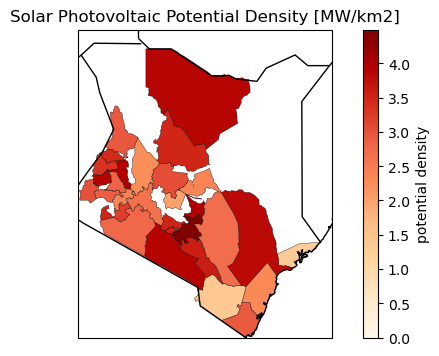

In [21]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',
       '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72',
       '74', '75', '76', '77', '78', '79', '81', '82', '83', '84', '85', '88',
       '89', '90', '91'],
      dtype='object', name='name')
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',

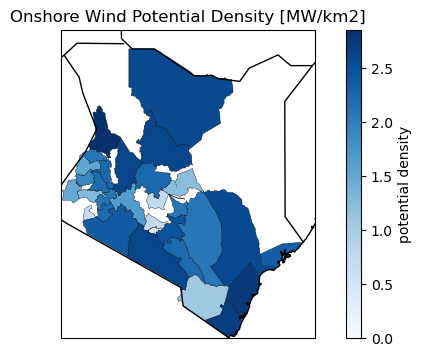

In [22]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Check annual expenditures

In [23]:
def _series_to_long_df(s: pd.Series, value_name: str) -> pd.DataFrame:
    """
    Convert a (possibly MultiIndex) Series to a long DataFrame with index levels as columns.
    """
    df = s.rename(value_name).reset_index()
    return df

# Get Series (often MultiIndex) and convert to mEUR
opex = (n.statistics.opex() / 1e6).astype(float)
capex = (n.statistics.capex() / 1e6).astype(float)
expanded_capex = (n.statistics.expanded_capex() / 1e6).astype(float)
revenue = (n.statistics.revenue() / 1e6).astype(float)

# Convert each to long DF
df_opex = _series_to_long_df(opex, "opex_mEUR")
df_capex = _series_to_long_df(capex, "capex_mEUR")
df_excap = _series_to_long_df(expanded_capex, "expanded_capex_mEUR")
df_rev = _series_to_long_df(revenue, "revenue_mEUR")

# Merge on common index columns (whatever they are)
idx_cols = [c for c in df_opex.columns if c != "opex_mEUR"]

df = df_opex.merge(df_capex, on=idx_cols, how="outer")
df = df.merge(df_excap, on=idx_cols, how="outer")
df = df.merge(df_rev, on=idx_cols, how="outer")

# Fill missing costs with 0 (not all cost types exist for all rows)
for col in ["opex_mEUR", "capex_mEUR", "expanded_capex_mEUR", "revenue_mEUR"]:
    if col in df.columns:
        df[col] = df[col].fillna(0.0)

In [24]:
df["excap-opex"] = df["opex_mEUR"] + df["expanded_capex_mEUR"]

In [25]:
df[["carrier", "excap-opex"]]

,carrier,excap-opex
0,Combined-Cycle Gas,0.000000
1,Geothermal,738.724570
2,Offshore Wind (AC),0.000041
3,Offshore Wind (DC),0.000040
4,Oil,0.000000
5,Onshore Wind,0.016825
6,Run of River,0.008183
7,Solar,0.010001
8,load,0.000883
9,AC,0.000116


In [26]:
#selected = ["Solar"]
#selected = ["Geothermal"]
selected = ["H2 electrolysis", "H2 fuel cell", "battery charger", "battery discharger", "Battery Storage", "Hydrogen Storage"]

share = (
    df.loc[df["carrier"].isin(selected), "excap-opex"].sum()
    / df["excap-opex"].sum()
    *100
)

print(f"{share:.0f}%")

8%


In [27]:
n.objective/1e6

805.4153242542753